<a href="https://colab.research.google.com/github/ksmorozov7/Portfolio/blob/main/LSTM_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Задание:**

Задание выполняется на Python. Необходимо выполнить прогнозирование временного ряда синусоидального сигнала с помощью рекуррентной нейронной сети LSTM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.callbacks import ModelCheckpoint


**Этап 1: Генерация синусоидальных данных**

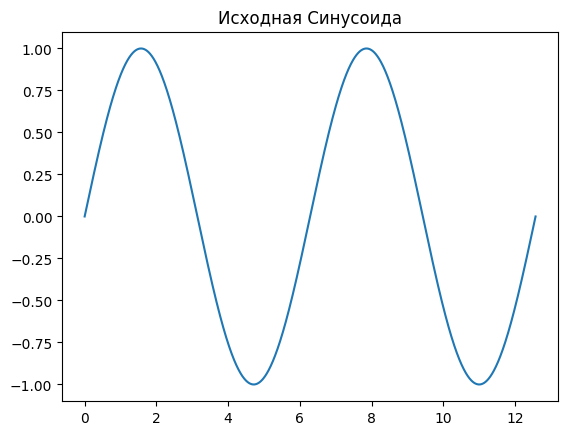

In [ ]:
time_points = np.linspace(0, 4 * np.pi, int(4 * np.pi * 100))
sin_wave = np.sin(time_points)
plt.plot(time_points, sin_wave)
plt.title('Исходная Синусоида')
plt.show()


**Этап 2: Нормализация данных синусоиды**

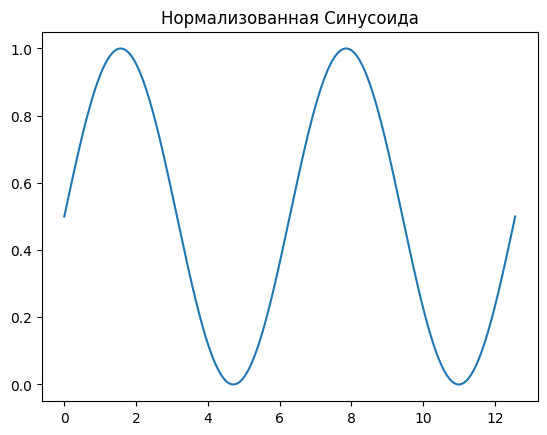

In [ ]:
amplitude = np.ptp(sin_wave)  # Размах амплитуды
normalized_wave = (sin_wave - np.min(sin_wave)) / amplitude
plt.plot(time_points, normalized_wave)
plt.title('Нормализованная Синусоида')
plt.show()


**Этап 3: Разделение на обучающую и тестовую выборку**

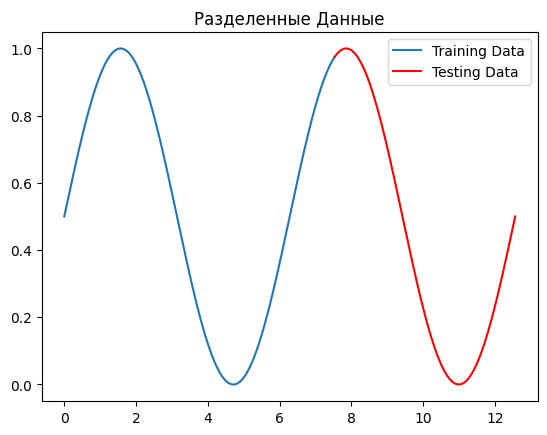

In [ ]:
training_ratio = 0.6
training_size = int(len(normalized_wave) * training_ratio)
training_data = normalized_wave[:training_size]
testing_data = normalized_wave[training_size:]
training_time = time_points[:training_size]
testing_time = time_points[training_size:]

plt.plot(training_time, training_data, label='Training Data')
plt.plot(testing_time, testing_data, label='Testing Data', color='red')
plt.title('Разделенные Данные')
plt.legend()
plt.show()


**Этап 4: Функция для создания последовательностей**

In [ ]:
def create_sequences(data, seq_length):
    sequence_data = []
    target_data = []
    for i in range(len(data) - seq_length):
        sequence_data.append(data[i:i + seq_length])
        target_data.append(data[i + seq_length])
    return np.array(sequence_data), np.array(target_data)

sequence_length = 100
train_sequences, train_targets = create_sequences(training_data, sequence_length)
test_sequences, test_targets = create_sequences(testing_data, sequence_length)

print(f'Размеры тренировочных последовательностей: {train_sequences.shape}')
print(f'Размеры тренировочных целей: {train_targets.shape}')
print(f'Размеры тестовых последовательностей: {test_sequences.shape}')
print(f'Размеры тестовых целей: {test_targets.shape}')


Размеры тренировочных последовательностей: (653, 100)
Размеры тренировочных целей: (653,)
Размеры тестовых последовательностей: (403, 100)
Размеры тестовых целей: (403,)


**Этап 5: Определение и компиляция модели LSTM**

In [ ]:
model = Sequential([
    LSTM(5, input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='SGD', loss='mean_squared_error', metrics=['mse'])


**Этап 6: Контрольная точка для сохранения наилучшей модели**

In [ ]:
checkpoint_path = 'best_model.keras'
checkpoint = ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1)


**Этап 7: Обучение модели**

In [ ]:
model.fit(train_sequences.reshape((-1, sequence_length, 1)), train_targets,
          epochs=50, batch_size=32,
          validation_split=0.2, callbacks=[checkpoint])


Epoch 1/50
10/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2811e-04 - mse: 6.2811e-04 
Epoch 1: val_loss did not improve from 0.00038
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.2376e-04 - mse: 6.2376e-04 - val_loss: 4.5510e-04 - val_mse: 4.5510e-04
Epoch 2/50
14/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.9373e-04 - mse: 5.9373e-04
Epoch 2: val_loss did not improve from 0.00038
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.9662e-04 - mse: 5.9662e-04 - val_loss: 4.6417e-04 - val_mse: 4.6417e-04
Epoch 3/50
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.5756e-04 - mse: 6.5756e-04
Epoch 3: val_loss did not improve from 0.00038
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6.4305e-04 - mse: 6.4305e-04 - val_loss: 4.3261e-04 - val_mse: 4.3261e-04
Epoch 4/50
 9/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.8126e-04 - mse: 5.8126e-04 
Epoch 4: val_loss did not improve from 0.00038
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.9032e-04 - mse: 5.9032e-04 - val_loss: 4.2535e-

**Этап 8: Оценка модели на тестовых данных**

In [ ]:
test_loss, test_mse = model.evaluate(test_sequences.reshape(-1, sequence_length, 1), test_targets)
print(f'Среднеквадратическая ошибка на тестовых данных: {test_mse:.5f}')


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.7024e-04 - mse: 5.7024e-04 
Среднеквадратическая ошибка на тестовых данных: 0.00067


**Этап 9: Прогнозирование на тестовых данных**

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


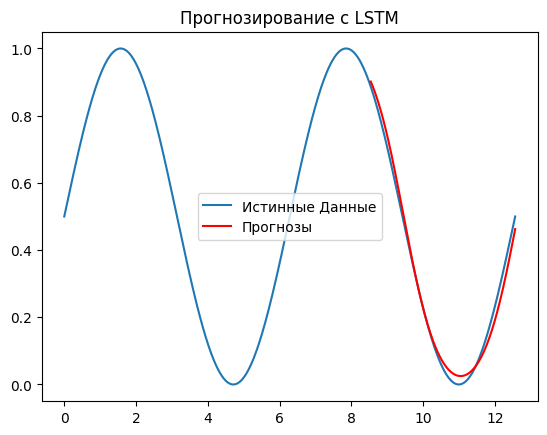

In [ ]:
predictions = model.predict(test_sequences.reshape(-1, sequence_length, 1))

plt.plot(time_points, normalized_wave, label='Истинные Данные')
plt.plot(testing_time[sequence_length:], predictions.flatten(), label='Прогнозы', color='red')
plt.title('Прогнозирование с LSTM')
plt.legend()
plt.show()
